# Lag plots 
These are used to visually check autocorrelation, non-linearity, stationarity, and time-series relationships.

Below you get:

✔ Basic Lag Plot
✔ Multi-lag grid
✔ Lag vs Lag scatter matrix
✔ Seasonal lag plot
✔ Autocorrelation fan plot
✔ Lag plot with regression line
✔ Lag plot for differenced series
✔ Lag plot for rolling-window lags
✔ Beautiful seaborn-styled versions

All code is ready-to-run.

## Basic Lag Plot (Pandas Built-in)

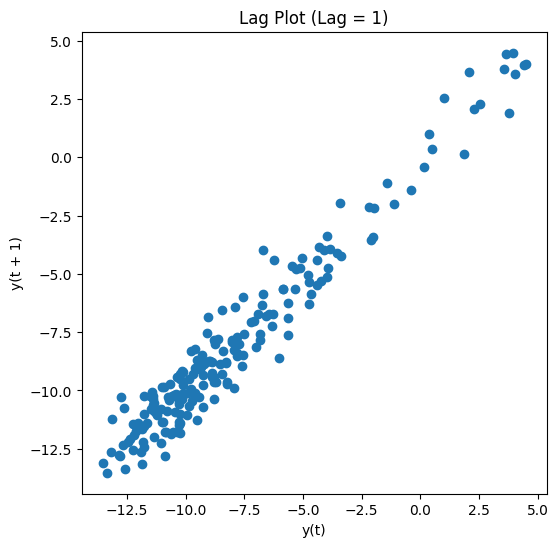

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot

# Sample series
np.random.seed(42)
data = np.cumsum(np.random.randn(200))
series = pd.Series(data)

plt.figure(figsize=(6, 6))
lag_plot(series)
plt.title("Lag Plot (Lag = 1)")
plt.show()


## Lag Plot for ANY lag (k)

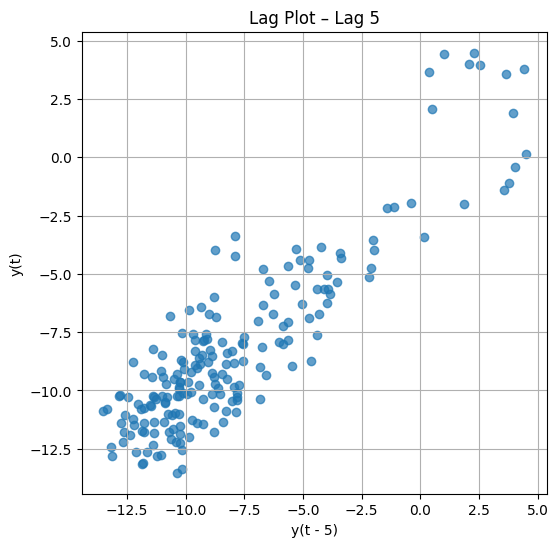

In [2]:
def lag_plot_k(series, k=1):
    plt.figure(figsize=(6, 6))
    plt.scatter(series[:-k], series[k:], alpha=0.7)
    plt.xlabel(f"y(t - {k})")
    plt.ylabel("y(t)")
    plt.title(f"Lag Plot – Lag {k}")
    plt.grid(True)
    plt.show()

lag_plot_k(series, k=5)


## Multi-Lag Plot Grid (Lag 1 → 12)

This is one of the most useful visualizations.


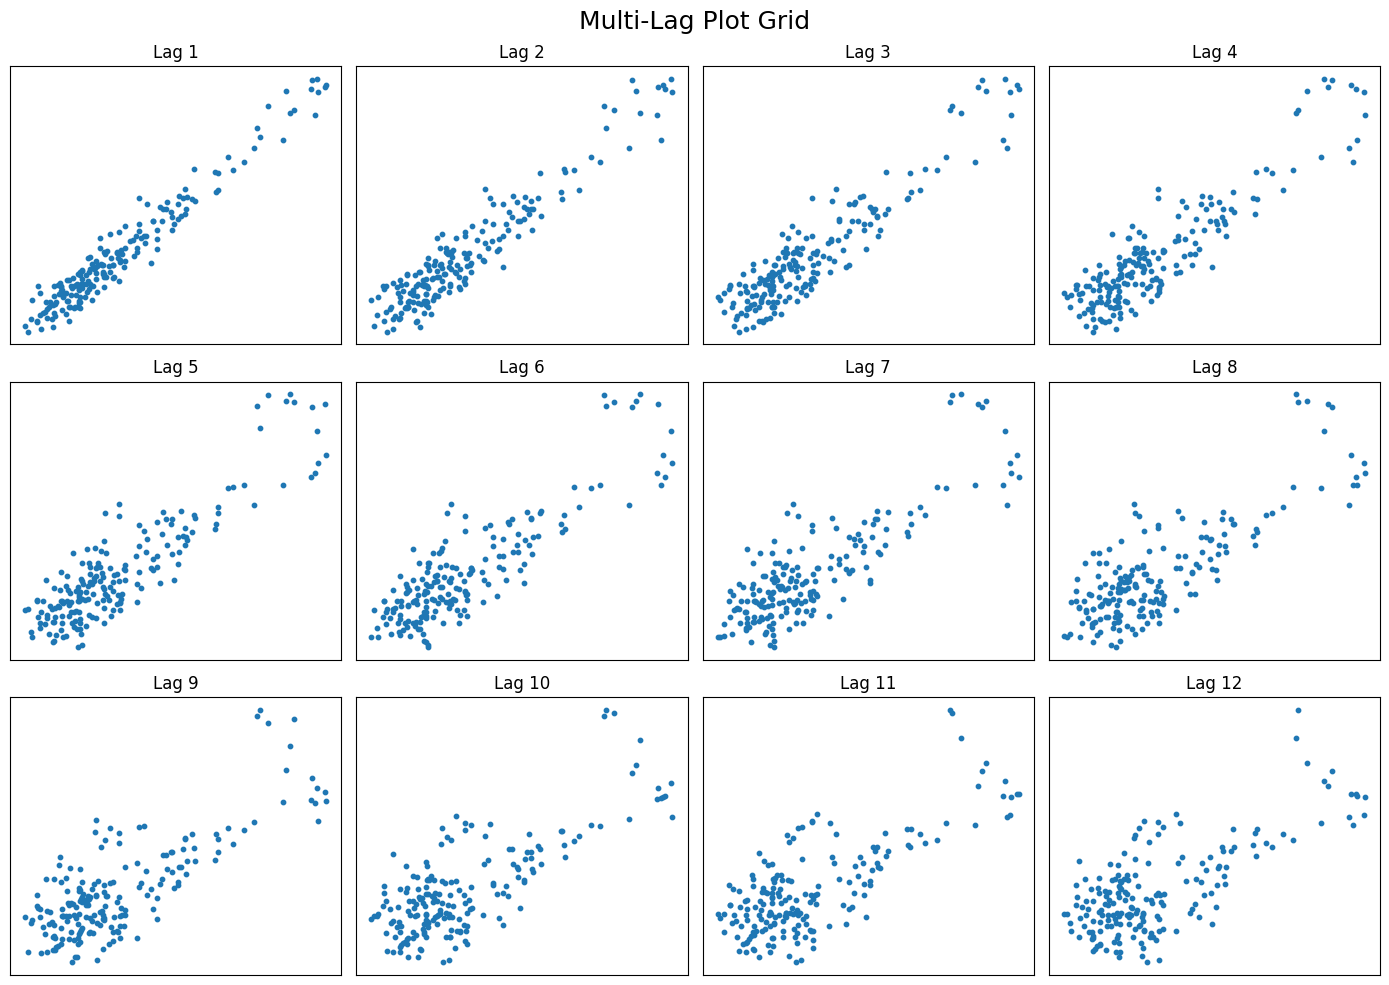

In [3]:
lags = 12
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Multi-Lag Plot Grid", fontsize=18)

for i in range(1, lags+1):
    ax = axes[(i-1)//4][(i-1)%4]
    ax.scatter(series[:-i], series[i:], s=10)
    ax.set_title(f"Lag {i}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## Lag Scatter Matrix (like Seaborn Pairplot)

c:\Users\NIL\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\NIL\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\NIL\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\NIL\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_in

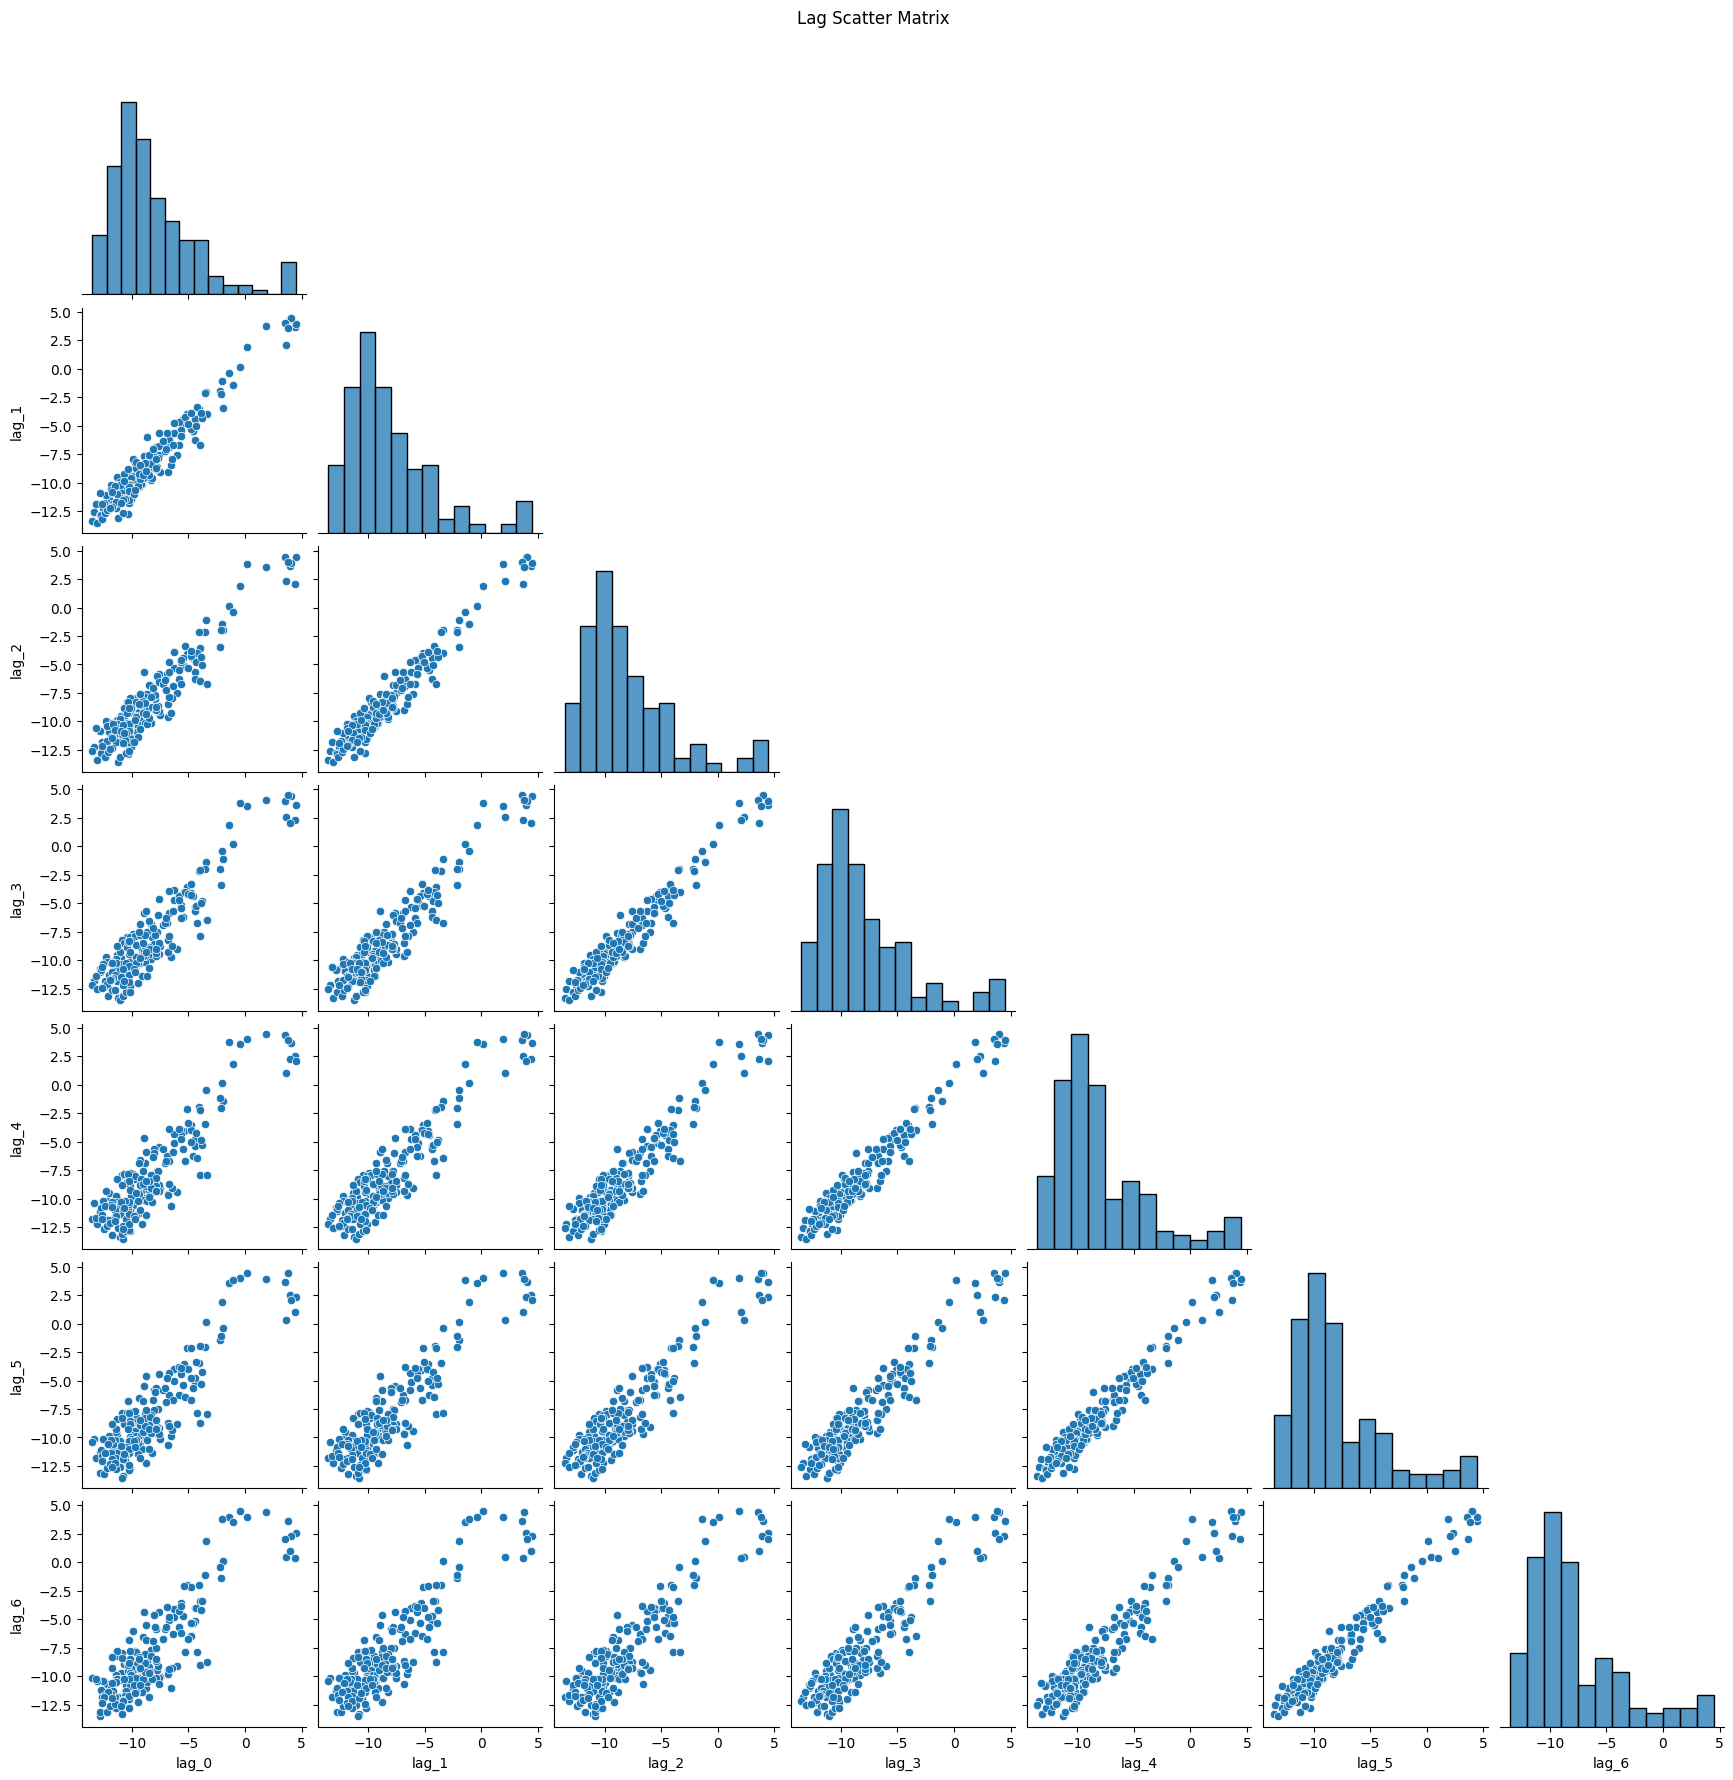

In [5]:
import seaborn as sns
lags = 6
df_lags = pd.DataFrame({
    f"lag_{i}": series.shift(i) for i in range(lags+1)
}).dropna()

sns.pairplot(df_lags, corner=True)
plt.suptitle("Lag Scatter Matrix", y=1.02)
plt.show()


## Seasonal Lag Plot (Lag = 7, 12, 24, etc.)

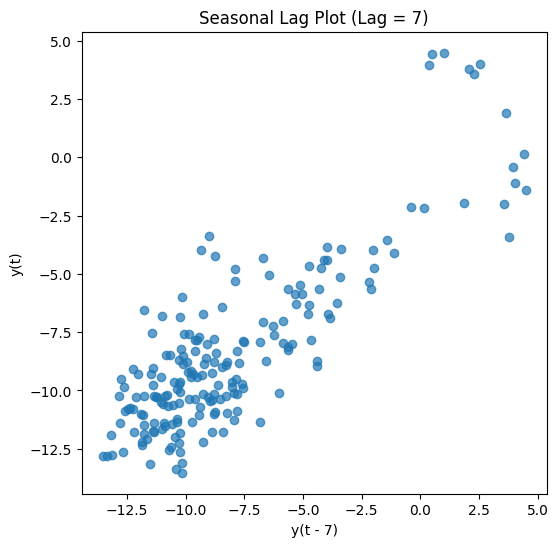

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(series[:-7], series[7:], alpha=0.7)
plt.xlabel("y(t - 7)")
plt.ylabel("y(t)")
plt.title("Seasonal Lag Plot (Lag = 7)")
plt.show()


## Lag Plot with Regression Line

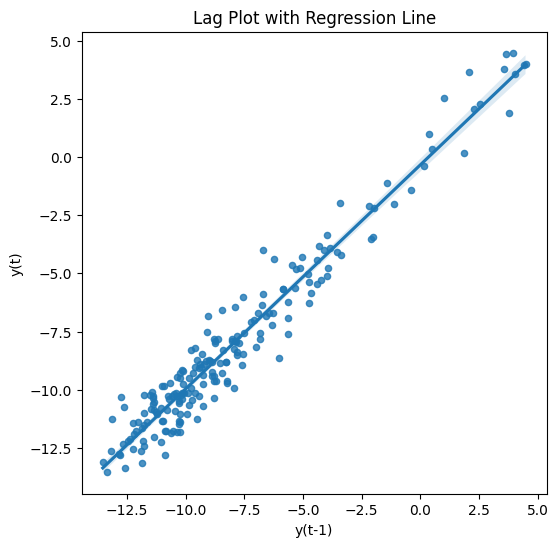

In [7]:
import seaborn as sns

plt.figure(figsize=(6,6))
sns.regplot(x=series[:-1], y=series[1:], scatter_kws={'s':20})
plt.title("Lag Plot with Regression Line")
plt.xlabel("y(t-1)")
plt.ylabel("y(t)")
plt.show()


## Lag Plot for Differenced Series (Stationary Check)

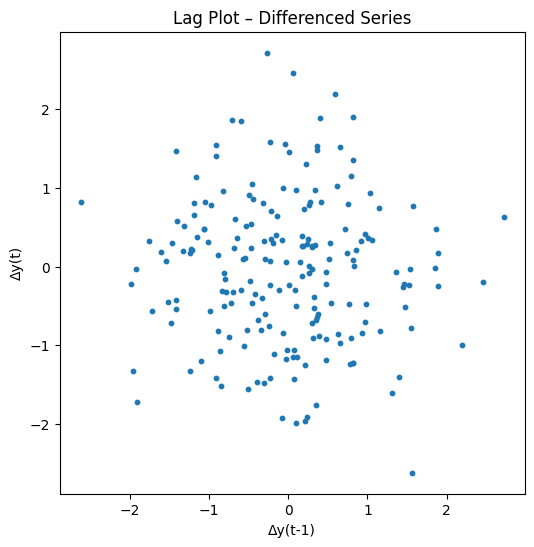

In [8]:
diff = series.diff().dropna()

plt.figure(figsize=(6,6))
plt.scatter(diff[:-1], diff[1:], s=10)
plt.title("Lag Plot – Differenced Series")
plt.xlabel("Δy(t-1)")
plt.ylabel("Δy(t)")
plt.show()


## Rolling Lag Plot (Sliding Window)

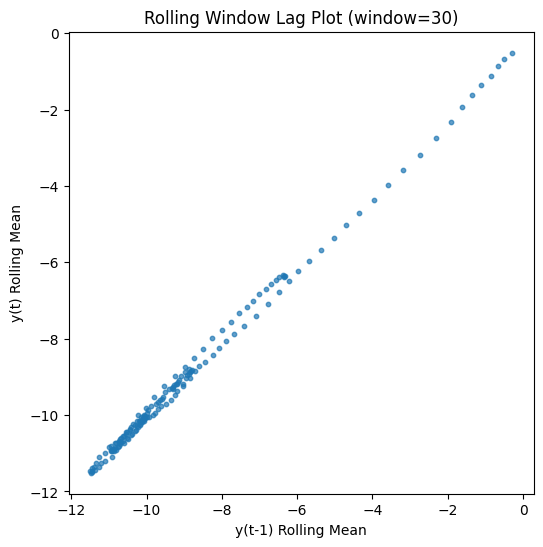

In [9]:
window = 30
x = series[:-1].rolling(window).mean()
y = series[1:].rolling(window).mean()

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=10, alpha=0.7)
plt.title("Rolling Window Lag Plot (window=30)")
plt.xlabel("y(t-1) Rolling Mean")
plt.ylabel("y(t) Rolling Mean")
plt.show()


## Fancy: Lag-Fan Plot (Multiple lags on one axis)

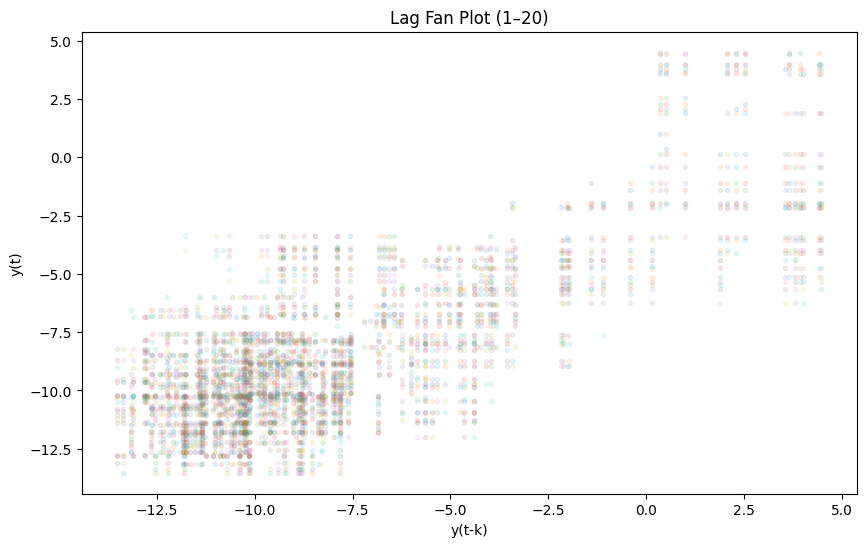

In [10]:
lags = 20
plt.figure(figsize=(10,6))

for k in range(1, lags+1):
    plt.plot(series[:-k], series[k:], ".", alpha=0.1)

plt.title("Lag Fan Plot (1–20)")
plt.xlabel("y(t-k)")
plt.ylabel("y(t)")
plt.show()


## Heatmap of Lag Correlations

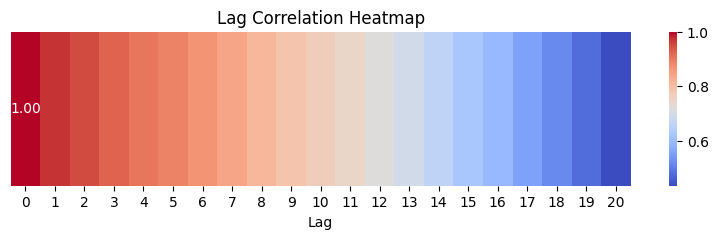

In [11]:
lags = 20
corrs = [series.autocorr(lag=i) for i in range(lags+1)]

plt.figure(figsize=(10,2))
sns.heatmap(np.array(corrs).reshape(1,-1),
            cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Lag Correlation Heatmap")
plt.yticks([]); plt.xlabel("Lag")
plt.show()
